In [21]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [22]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [103]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.00
        self._prev = set(_children) # Parents (but inverted naming, since children in backpropagation)
        self._op = _op
        self.label = label
        self._backward = lambda: None # No op for leaf nodes

    def __repr__(self):
        return f"Value({self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad += 1.00 * out.grad
            other.grad += 1.00 * out.grad
        out._backward = _backward
        
        return out

    def __radd__(self, other):
        return self + other
        
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    def __rmul__(self, other):
        return self * other
    
    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __truediv__(self, other):
        return self * other**-1
        
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self,), f"**{other}")

        def _backward():
            self.grad += (other * (self.data ** (other-1))) * out.grad
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out
            
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), "tanh")

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
                

In [184]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi*wx for wi, wx in zip(self.w, x)), self.b) # Starts adding from self.b
        out = act.tanh()
        return out
        
    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]
        
class MLP:
    def __init__(self, nin, nouts):
        size = [nin] + nouts # nouts is number of outputs per layer (so 0th index = 1st layer output in combined list)
        self.layers = [Layer(size[i], size[i + 1]) for i in range(len(nouts))]
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [185]:
n = MLP(3, [4, 4, 1]) # 3 inputs, 4 hidden_1 outputs, 4 hidden_2 outputs, 1 final output
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # Target outputs

In [193]:
for k in range(20):
    # Forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for yout, ygt in zip(ypred, ys))

    # Backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # Update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 0.001130704014926933
1 0.001127788441508265
2 0.0011248874355221116
3 0.001122000889337612
4 0.001119128696374691
5 0.0011162707510912516
6 0.0011134269489707093
7 0.0011105971865095305
8 0.0011077813612051118
9 0.0011049793715437004
10 0.0011021911169886395
11 0.0010994164979685698
12 0.0010966554158660304
13 0.0010939077730060549
14 0.0010911734726449607
15 0.0010884524189594057
16 0.0010857445170354533
17 0.0010830496728578716
18 0.0010803677932995682
19 0.0010776987861111737


In [194]:
ypred

[Value(0.9886990944268816),
 Value(-0.9789936441614665),
 Value(-0.9859829449150082),
 Value(0.982329586861993)]

In [79]:
# Inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# Weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# Bias b
b = Value(6.8813735870195432, label="b")

# Neuron x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label = "x1w1"
x2w2 = x2 * w2; x2w2.label = "x2w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1x2w2"
n = x1w1x2w2 + b; n.label = "n"

# # Activation tanh
# o = n.tanh(); o.label = "o"

# Alternative tanh
e = (2*n).exp(); e.label = "e
o = (e - 1) / (e + 1); o.label = "o"

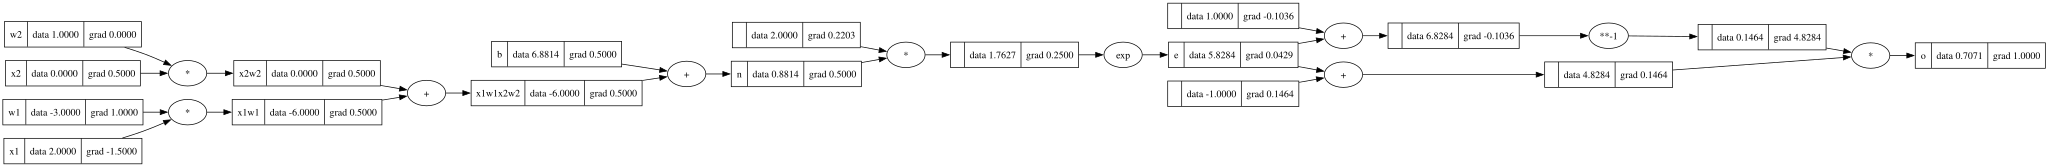

In [80]:
o.backward()
draw_dot(o)